In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf 
import scipy.sparse as sp
from recommenders.evaluation.python_evaluation import (
    map_at_k,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)

import LightGCN
from utils import (get_top_k_scored_items, 
                   nCoreReduction, 
                   user_fixed_train_test_split,
                   separate_by_gender)

import matplotlib.pyplot as plt 

import importlib 

import ActiveLearner

# disable the SettingWithCopyWarning
pd.options.mode.chained_assignment = None

seed=42

## Load data

In [2]:
data_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
data_columns = ['user_id', 'item_id', 'rating', 'timestamp']

user_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.user"
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [3]:
data_df = pd.read_csv(data_url, sep='\t', names=data_columns, header=None)
user_df = pd.read_csv(user_url, sep='|', names=user_columns, header=None)

In [4]:
# shuffle data_df
data_df = data_df.sample(frac=1, random_state=seed).reset_index(drop=True)

## Dimensionality reduction

In [5]:
ncore_data_df = nCoreReduction(data_df)

In [6]:
print(f"The original data frame shape: {data_df.shape}")
print(f"  - # users: {data_df['user_id'].nunique()}")
print(f"  - # items: {data_df['item_id'].nunique()}")
print('\n')

print(f"The filtered data frame shape: {ncore_data_df.shape}")
print(f"  - # users: {ncore_data_df['user_id'].nunique()}")
print(f"  - # items: {ncore_data_df['item_id'].nunique()}")

The original data frame shape: (100000, 4)
  - # users: 943
  - # items: 1682


The filtered data frame shape: (99032, 4)
  - # users: 943
  - # items: 1298


## Convert id to inner id

In [7]:
unique_users = ncore_data_df['user_id'].unique()
user_id_to_iid = {id: iid for iid, id in enumerate(unique_users)}
user_iid_to_id = {iid: id for iid, id in enumerate(unique_users)}

unique_items = ncore_data_df['item_id'].unique()
item_id_to_iid = {id: iid for iid, id in enumerate(unique_items)}
item_iid_to_id = {iid: id for iid, id in enumerate(unique_items)}

In [8]:
n_users = unique_users.shape[0]
n_items = unique_items.shape[0]

In [9]:
ncore_data_df['user_iid'] = ncore_data_df['user_id'].map(user_id_to_iid)
ncore_data_df['item_iid'] = ncore_data_df['item_id'].map(item_id_to_iid)

# apply to `user_df`` as well
user_df['user_iid'] = user_df['user_id'].map(user_id_to_iid)

In [10]:
iid_to_gender = dict(zip(user_df['user_iid'], user_df['gender']))

In [11]:
n_pro, n_unpro = user_df['gender'].value_counts()[['F', 'M']]
print(f"Number of female users: {n_pro}")
print(f"Number of male users: {n_unpro}")

Number of female users: 273
Number of male users: 670


## Female/male separation experiment - personalized active learning

### Train test split (user-fixed)

In [59]:
train_df, test_df = user_fixed_train_test_split(ncore_data_df, test_size=0.2, random_state=seed)

In [60]:
# get female/male training set
pro_tr_df, unpro_tr_df = separate_by_gender(train_df, iid_to_gender)

In [61]:
# get female test set
pro_te_df, _ = separate_by_gender(test_df, iid_to_gender)

### Mix different percentage of male training set with female training set

In [66]:
# hyper-parameter for rec sys
hparams = {
    'epochs': 50,
    'learning_rate': 0.005,
    'embed_size': 64,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}

# parameters for evaluation functions
eval_params = {
    'k': 10,
    'col_user': 'user_iid',
    'col_item': 'item_iid',
    'col_prediction': 'rating_estimate',
}

n_iters = 5

In [67]:
unpro_percentage = np.linspace(0.0, 1.0, 11, endpoint=True)

In [70]:
results = []

for iter in range(n_iters):
    for p in unpro_percentage:
        sampled_unpro_tr_df = unpro_tr_df.sample(frac=p, replace=False, random_state=iter, ignore_index=True)
        combined_tr_df = pd.concat([pro_tr_df, sampled_unpro_tr_df], axis=0, ignore_index=True)
        combined_tr_df = combined_tr_df.sample(frac=1, random_state=iter).reset_index(drop=True)
        
        model = LightGCN.LightGCNRecommender(
            hparams=hparams,
            tr_df=combined_tr_df[['user_iid', 'item_iid', 'rating']],
            te_df=test_df[['user_iid', 'item_iid', 'rating']],
            n_users=n_users,
            n_items=n_items,
            seed=iter,
        )
        model.fit()
        
        pro_topk_scores = model.recommend_k_items(pro_te_df, top_k=10, remove_seen=True)
        pro_map = map_at_k(pro_te_df, pro_topk_scores, **eval_params)
        pro_ndcg = ndcg_at_k(pro_te_df, pro_topk_scores, **eval_params)
        pro_precision = precision_at_k(pro_te_df, pro_topk_scores, **eval_params)
        pro_recall = recall_at_k(pro_te_df, pro_topk_scores, **eval_params)
        
        result = {
            'unpro_percentage': p,
            'pro_map': pro_map,
            'pro_ndcg': pro_ndcg,
            'pro_precision': pro_precision,
            'pro_recall': pro_recall,
        }

        results.append(result)

In [71]:
results_df = pd.DataFrame(results)

### Plots

In [74]:
results_df.columns

Index(['unpro_percentage', 'pro_map', 'pro_ndcg', 'pro_precision',
       'pro_recall'],
      dtype='object')

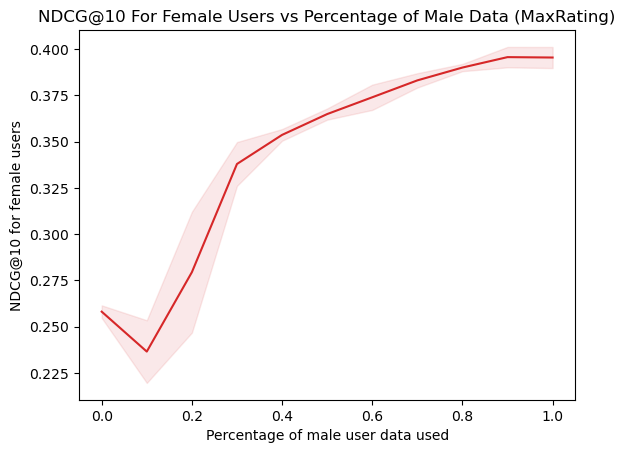

In [79]:
# ndcg
pro_df_grouped = results_df.groupby('unpro_percentage').agg(['mean', 'std', 'count'])['pro_ndcg']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

plt.plot(unpro_percentage, pro_df_grouped['mean'], color='tab:red')
plt.fill_between(
    unpro_percentage,
    pro_df_grouped['ci_lower'],
    pro_df_grouped['ci_upper'],
    color='tab:red',
    alpha=.1
)

plt.xlabel('Percentage of male user data used')
plt.ylabel('NDCG@10 for female users')

plt.title("NDCG@10 For Female Users vs Percentage of Male Data (MaxRating)")
plt.show()

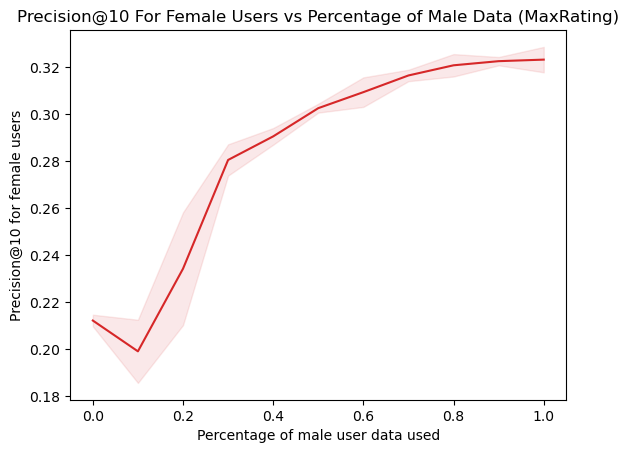

In [80]:
# precision
pro_df_grouped = results_df.groupby('unpro_percentage').agg(['mean', 'std', 'count'])['pro_precision']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

plt.plot(unpro_percentage, pro_df_grouped['mean'], color='tab:red')
plt.fill_between(
    unpro_percentage,
    pro_df_grouped['ci_lower'],
    pro_df_grouped['ci_upper'],
    color='tab:red',
    alpha=.1
)

plt.xlabel('Percentage of male user data used')
plt.ylabel('Precision@10 for female users')

plt.title("Precision@10 For Female Users vs Percentage of Male Data (MaxRating)")
plt.show()

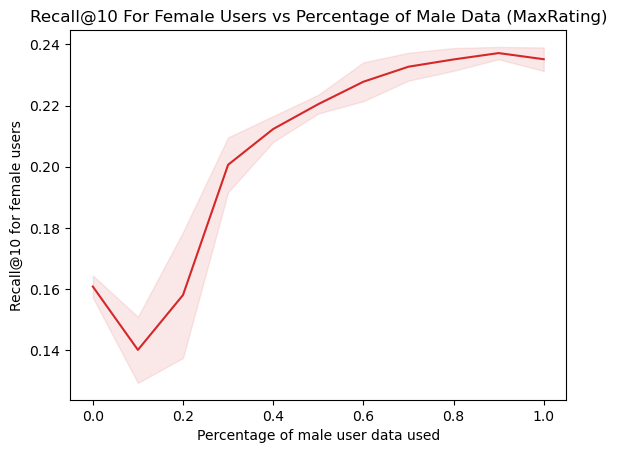

In [81]:
# recall
pro_df_grouped = results_df.groupby('unpro_percentage').agg(['mean', 'std', 'count'])['pro_recall']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

plt.plot(unpro_percentage, pro_df_grouped['mean'], color='tab:red')
plt.fill_between(
    unpro_percentage,
    pro_df_grouped['ci_lower'],
    pro_df_grouped['ci_upper'],
    color='tab:red',
    alpha=.1
)

plt.xlabel('Percentage of male user data used')
plt.ylabel('Recall@10 for female users')

plt.title("Recall@10 For Female Users vs Percentage of Male Data (MaxRating)")
plt.show()

## Oversampling experiment

In [12]:
train_df, test_df = user_fixed_train_test_split(ncore_data_df, test_size=0.2, random_state=42)

In [13]:
# hyper-parameters

# hyper-parameter for rec sys
hparams = {
    'epochs': 50,
    'learning_rate': 0.005,
    'embed_size': 64,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}


n_iters = 1   # number of repeated experiments
n_epochs = 26 # epoch of active learning process
q = 50        # active learning query list size

In [14]:
MaxRating_results_lst = []
for iter in range(n_iters):
    print('------------------------------------')
    print('------------------------------------')
    print(f'Starting the Equal Ratio Active Learning process, iteration {iter+1}')
    al = ActiveLearner.RatingBasedActiveLearner(
        strategy = 'MaxRating', 
        model = LightGCN.LightGCNRecommender,
        model_hparams=hparams,
        tr_df=train_df[['user_iid', 'item_iid', 'rating']],
        te_df=test_df[['user_iid', 'item_iid', 'rating']],
        n_users=n_users,
        n_items=n_items,
        iid_to_gender=iid_to_gender,
        q=q,
        seed=iter,
        oversample=True,
        ratio=None,
    )
    MaxRating_results_lst.append([])
    for epoch in range(n_epochs):
        print('------------------------------------')
        print(f'Epoch: {epoch+1}')
        # print(f'# of ratings elicited: {al.kn_df.shape[0]}')
        # print(f'Percentage of ratings elicited: {100*(al.kn_df.shape[0]/train_df.shape[0]):.2f}%')
        results = al.run_epoch()
        MaxRating_results_lst[-1].append(results)

------------------------------------
------------------------------------
Starting the Equal Ratio Active Learning process, iteration 1
------------------------------------
Epoch: 1
------------------------------------
Epoch: 2
------------------------------------
Epoch: 3
------------------------------------
Epoch: 4
------------------------------------
Epoch: 5
------------------------------------
Epoch: 6
------------------------------------
Epoch: 7
------------------------------------
Epoch: 8
------------------------------------
Epoch: 9
------------------------------------
Epoch: 10
------------------------------------
Epoch: 11
------------------------------------
Epoch: 12
------------------------------------
Epoch: 13
------------------------------------
Epoch: 14
------------------------------------
Epoch: 15
------------------------------------
Epoch: 16
------------------------------------
Epoch: 17
------------------------------------
Epoch: 18
---------------------------

In [15]:
df_lst = []
for iter in range(n_iters):
    results = MaxRating_results_lst[iter]
    d = {}
    d['epoch'] = list(range(n_epochs))
    d['percentage'] = [r['percentage'] for r in results]
    d['map_pro'] = [r['map_pro'] for r in results]
    d['map_unpro'] = [r['map_unpro'] for r in results]
    d['ndcg_pro'] = [r['ndcg_pro'] for r in results]
    d['ndcg_unpro'] = [r['ndcg_unpro'] for r in results]
    d['precision_pro'] = [r['precision_pro'] for r in results]
    d['precision_unpro'] = [r['precision_unpro'] for r in results]
    d['recall_pro'] = [r['recall_pro'] for r in results]
    d['recall_unpro'] = [r['recall_unpro'] for r in results]
    d['count_pro'] = [r['count_pro'] for r in results]
    d['count_unpro'] = [r['count_unpro'] for r in results]
    df = pd.DataFrame.from_dict(d)
    df_lst.append(df)

MaxRating_results_df = pd.concat(df_lst, axis=0, ignore_index=True)

### Plots

In [17]:
percentages = MaxRating_results_df.groupby('epoch')['percentage'].agg('mean')

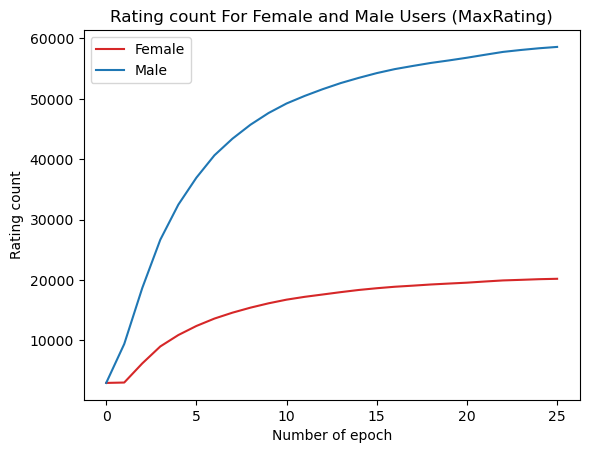

In [18]:
# count
pro_df_grouped = MaxRating_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['count_pro']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

unpro_df_grouped = MaxRating_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['count_unpro']
unpro_df_grouped['ci'] = 1.95 * unpro_df_grouped['std'] / np.sqrt(unpro_df_grouped['count'])
unpro_df_grouped['ci_lower'] = unpro_df_grouped['mean'] - unpro_df_grouped['ci']
unpro_df_grouped['ci_upper'] = unpro_df_grouped['mean'] + unpro_df_grouped['ci']

plt.plot(np.arange(n_epochs), pro_df_grouped['mean'], color='tab:red', label="Female")

plt.plot(np.arange(n_epochs), unpro_df_grouped['mean'], color='tab:blue', label="Male")

plt.xlabel('Number of epoch')
plt.ylabel('Rating count')

plt.legend()
plt.title("Rating count For Female and Male Users (MaxRating)")
plt.show()